<a href="https://colab.research.google.com/github/psycholinguistics-proj/proj/blob/main/Relevant_Analysis_from_D1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Run these first
`Ctrl` + `Enter` to run the cell and stay in that cell
`Shift` + `Enter` to run the cell and move to the next cell

In [1]:
!apt-get install -y fonts-nanum


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [2]:
!fc-cache -fv
!rm ~/.cache/matplotlib -rf


/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped directory detected
/var/cache/fontconfig: cleaning cache directory
/root/.cache/fontconfig: not cleaning non-existent cache directory
/root/.fontconfig: not cleaning non-existent cache director

In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Configure font
plt.rc('font', family='NanumBarunGothic')
# Fix minus sign issues
mpl.rcParams['axes.unicode_minus'] = False


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import zscore


In [5]:

# Load the excel file from Drive
df = pd.read_excel('/content/KLP_DB_final.xlsx', sheet_name='KLP_DB_final')

# Filter to words only
df_words = df[df['Lexicality'] == 1].copy()

# Log transform frequency
df_words['LogFreq'] = np.log(df_words['Freq'].replace('NA', np.nan).astype(float))


In [6]:
# Filtering the data to the correct sample
key_vars = ['MRT', 'MHIT', 'LogFreq', 'syltkn1', 'syltkn2', 'syllbdy1', 'syllbdy2', 'rhym1', 'rhym2']
df_words = df_words.dropna(subset=key_vars)
print(f'Full word sample: {len(df_words)} words')

# Restricted sample matching original paper (syllable freq 15-50 only on freq range, not syll freq)
df_restricted = df_words[(df_words['Freq'] >= 15) & (df_words['Freq'] <= 50)].copy()
print(f'Restricted sample (Freq 15-50): {len(df_restricted)} words')


Full word sample: 4565 words
Restricted sample (Freq 15-50): 1778 words


# Main Analysis

## Partial Regression
* Everything was put in simultaneously, but we still need to do hierarchical regression (variables need to be entered in steps so we can report ΔR² at each step - this is necessary to tell us how much additional variance `syltkn2` explains beyond LogFreq and `syltkn1` combined)
* This is only like a pilot analysis so we can see direction and rough magnitude of the effects.
* `syltkn1` effect > `syltkn2` effect (5.8 ms vs 2.5 ms - see coefficients). This is consistent with the serial processing account - the first syllable is processed first and drives most of the lexical competition. Alvarez et al. (2000) already predicted this for Spanish.
* Skew -> residuals (difference between what the regression model predicted and what actually happened aka `actual MRT - predicted MRT`) are not symmetrical. More large positive residudals
* Kurtosis -> residual distribution shows that there are more extreme values than expected
* `syltkn1` - 5.8 ms vs original paper's ~10.8 ms per SD because this one used the full word sample rather than the restricted low-frequency subset the paper used.
* 2.5 ms for `syltkn2` means that the second syllable contributes to lexical competition (but the effect is smaller than the first syllable effect)

In [7]:
# Partial regression plots
df_clean = df_words[['MRT', 'LogFreq', 'syltkn1', 'syltkn2']].dropna()
X = sm.add_constant(df_clean[['LogFreq', 'syltkn1', 'syltkn2']])
y = df_clean['MRT']

df_clean['LogFreq_z'] = zscore(df_clean['LogFreq'])
df_clean['syltkn1_z'] = zscore(df_clean['syltkn1'])
df_clean['syltkn2_z'] = zscore(df_clean['syltkn2'])

X_std = sm.add_constant(df_clean[['LogFreq_z', 'syltkn1_z', 'syltkn2_z']])
model_std = sm.OLS(df_clean['MRT'], X_std).fit()
print('***********************************************************************')
print("The model AFTER predictors were standardized")
print(model_std.summary())


***********************************************************************
The model AFTER predictors were standardized
                            OLS Regression Results                            
Dep. Variable:                    MRT   R-squared:                       0.290
Model:                            OLS   Adj. R-squared:                  0.290
Method:                 Least Squares   F-statistic:                     622.0
Date:                Mon, 27 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:16:34   Log-Likelihood:                -25840.
No. Observations:                4565   AIC:                         5.169e+04
Df Residuals:                    4561   BIC:                         5.171e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------

## MRT Hierarchical Analysis (full real word list + low-freq list)
* Full sample - both `syltkn1` and `syltkn2` are significant. ΔR² at Step 3 is small (0.0009).
* Restricted sample - p = .5151 means that `syltkn2` is not significant (when restricted to low-frequency words)

In [8]:
# Main analysis: MRT models (hierarchical)

def run_hierarchical(df, dv='MRT'):
  df_c = df[['MRT', 'MHIT', 'LogFreq', 'syltkn1', 'syltkn2']].dropna()
  y = df_c[dv]

  # Step 1: control only
  m1 = sm.OLS(y, sm.add_constant(df_c[['LogFreq']])).fit()

  # Step 2: add syltkn1 (paper replication)
  m2 = sm.OLS(y, sm.add_constant(df_c[['LogFreq', 'syltkn1']])).fit()

  # Step 3: add syltkn2
  m3 = sm.OLS(y, sm.add_constant(df_c[['LogFreq', 'syltkn1', 'syltkn2']])).fit()

  print(f'\n--- {dv} Hierarchical Regression ---')
  print(f'Step 1: R²={m1.rsquared:.3f}')
  print(f'  LogFreq: β={m1.params["LogFreq"]:.4f}, p={m1.pvalues["LogFreq"]:.4f}')

  print(f'\nStep 2: R²={m2.rsquared:.3f}, ΔR²={m2.rsquared-m1.rsquared:.4f}')
  print(f'  LogFreq: β={m2.params["LogFreq"]:.4f}, p={m2.pvalues["LogFreq"]:.4f}')
  print(f'  syltkn1: β={m2.params["syltkn1"]:.6f}, p={m2.pvalues["syltkn1"]:.4f}')

  print(f'\nStep 3: R²={m3.rsquared:.3f}, ΔR²={m3.rsquared-m2.rsquared:.4f}')
  print(f'  LogFreq: β={m3.params["LogFreq"]:.4f}, p={m3.pvalues["LogFreq"]:.4f}')
  print(f'  syltkn1: β={m3.params["syltkn1"]:.6f}, p={m3.pvalues["syltkn1"]:.4f}')
  print(f'  syltkn2: β={m3.params["syltkn2"]:.6f}, p={m3.pvalues["syltkn2"]:.4f}')

  return m1, m2, m3

# Run on full sample
print('========= FULL SAMPLE =========')
m1, m2, m3 = run_hierarchical(df_words, dv='MRT')


# Run on restricted sample
print('\n========= RESTRICTED SAMPLE =========')
r1, r2, r3 = run_hierarchical(df_restricted, dv='MRT')


========= FULL SAMPLE =========

--- MRT Hierarchical Regression ---
Step 1: R²=0.285
  LogFreq: β=-33.1415, p=0.0000

Step 2: R²=0.289, ΔR²=0.0048
  LogFreq: β=-34.0503, p=0.0000
  syltkn1: β=0.000427, p=0.0000

Step 3: R²=0.290, ΔR²=0.0009
  LogFreq: β=-34.3585, p=0.0000
  syltkn1: β=0.000425, p=0.0000
  syltkn2: β=0.000186, p=0.0168

========= RESTRICTED SAMPLE =========

--- MRT Hierarchical Regression ---
Step 1: R²=0.019
  LogFreq: β=-32.1969, p=0.0000

Step 2: R²=0.025, ΔR²=0.0055
  LogFreq: β=-32.8002, p=0.0000
  syltkn1: β=0.000494, p=0.0016

Step 3: R²=0.025, ΔR²=0.0002
  LogFreq: β=-32.7859, p=0.0000
  syltkn1: β=0.000491, p=0.0016
  syltkn2: β=0.000103, p=0.5151


### MHIT Hierarchical Regression (including MHIT <100)
* negative coefficients mean that higher syllable token is associated with lower accuracy. (Makes sense: more competition -> more errors)
* Suggests speed and accuracy are being affected by the same mechanism, *not dissociating*.


In [9]:
# Parallel MHIT models
print('========= FULL SAMPLE =========')
mhit1, mhit2, mhit3 = run_hierarchical(df_words, dv='MHIT')

# Sub-ceiling (MHIT < 100)
df_subceil = df_words[df_words['MHIT'] < 100].copy()
print(f'\nSub-ceiling sample: {len(df_subceil)} words')
print('========= SUB-CEILING SAMPLE - MHIT =========')
mhit_s1, mhit_s2, mhit_s3 = run_hierarchical(df_subceil, dv='MHIT')

========= FULL SAMPLE =========

--- MHIT Hierarchical Regression ---
Step 1: R²=0.174
  LogFreq: β=6.3846, p=0.0000

Step 2: R²=0.179, ΔR²=0.0044
  LogFreq: β=6.5970, p=0.0000
  syltkn1: β=-0.000100, p=0.0000

Step 3: R²=0.181, ΔR²=0.0021
  LogFreq: β=6.7142, p=0.0000
  syltkn1: β=-0.000099, p=0.0000
  syltkn2: β=-0.000071, p=0.0006

Sub-ceiling sample: 3356 words
========= SUB-CEILING SAMPLE - MHIT =========

--- MHIT Hierarchical Regression ---
Step 1: R²=0.146
  LogFreq: β=7.3533, p=0.0000

Step 2: R²=0.150, ΔR²=0.0043
  LogFreq: β=7.5724, p=0.0000
  syltkn1: β=-0.000108, p=0.0000

Step 3: R²=0.152, ΔR²=0.0021
  LogFreq: β=7.6774, p=0.0000
  syltkn1: β=-0.000107, p=0.0000
  syltkn2: β=-0.000076, p=0.0043


## Effect Sizes (ms per SD) for MRT and MHIT

In [10]:
# Get SDs
sd_syltkn1 = df_words['syltkn1'].std()
sd_syltkn2 = df_words['syltkn2'].std()
sd_logfreq = df_words['LogFreq'].std()


# Access coefficients directly from the model object
print('=== MRT Step 3 — effect sizes ===')
print(f'LogFreq:  {m3.params["LogFreq"] * sd_logfreq:.2f} ms per SD')
print(f'syltkn1:  {m3.params["syltkn1"] * sd_syltkn1:.2f} ms per SD')
print(f'syltkn2:  {m3.params["syltkn2"] * sd_syltkn2:.2f} ms per SD')

print()
print('=== MHIT sub-ceiling Step 3 — effect sizes ===')
print(f'LogFreq:  {mhit_s3.params["LogFreq"] * sd_logfreq:.2f} % per SD')
print(f'syltkn1:  {mhit_s3.params["syltkn1"] * sd_syltkn1:.2f} % per SD')
print(f'syltkn2:  {mhit_s3.params["syltkn2"] * sd_syltkn2:.2f} % per SD')

=== MRT Step 3 — effect sizes ===
LogFreq:  -45.64 ms per SD
syltkn1:  5.83 ms per SD
syltkn2:  2.50 ms per SD

=== MHIT sub-ceiling Step 3 — effect sizes ===
LogFreq:  10.20 % per SD
syltkn1:  -1.47 % per SD
syltkn2:  -1.02 % per SD


### Overall Findings from Phase 1
1. Replication of effect of first-syllable token freq on MRT replicates in both the full sample and restricted low-freq sample. Consistent with the original paper.
2. Second-syllable token freq predicts MRT in the full sample (β = +0.000186, p = .017, which was standardized to +2.50ms per standard deviation). Suggests second-syllable competition contributes additional inhibition. Consistent with partial parallel processing?
**IMPORTANT NOTE**: effect does not replicate in restricted low-freq sample (p = .515)
3. Both `syltkn1` and `syltkn2` significantly predict MHIT in the negative direction in both the full sample and sub-ceiling (MHIT < 100) sample. Speed and accuracy are not dissociating (they are affected by the same mechanism)
4. `Freq` x `syltkn2` is not significant. The second-syllable effect does nto vary as a function of word frequency.

## Frequency Quartile

In [11]:
# Create frequency quartiles
# Only use words that have Freq data (not NA)
df_q = df_words[['MRT', 'LogFreq', 'syltkn1', 'syltkn2', 'Freq']].dropna().copy()

df_q['FreqQuartile'] = pd.qcut(df_q['Freq'],
                                q=4,
                                labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)'])

# Check how many words per quartile
print('Words per quartile:')
print(df_q['FreqQuartile'].value_counts().sort_index())
print()

# Run regression within each quartile
sd_syltkn2 = df_words['syltkn2'].std()
results = []
print(f'{"Quartile":<15} {"n":>5} {"syltkn2 β":>12} {"SE":>10} {"t":>8} {"p":>8} {"sig":>6} {"   | effect (ms per SD)":>6}')
print('-' * 95)

for q in ['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)']:
    subset = df_q[df_q['FreqQuartile'] == q]
    X = sm.add_constant(subset[['LogFreq', 'syltkn1', 'syltkn2']])
    m = sm.OLS(subset['MRT'], X).fit()

    b = m.params['syltkn2']
    se = m.bse['syltkn2']
    t = m.tvalues['syltkn2']
    p = m.pvalues['syltkn2']
    ci_low = m.conf_int().loc['syltkn2', 0]
    ci_high = m.conf_int().loc['syltkn2', 1]
    sig = '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else 'n.s.'
    effect = b * sd_syltkn2

    print(f'{q:<15} {len(subset):>5} {b:>12.6f} {se:>10.6f} {t:>8.3f} {p:>8.4f}  {sig:>7}  | {effect:>8.2f}')

    results.append({
        'quartile': q,
        'n': len(subset),
        'beta': b,
        'se': se,
        'ci_low': ci_low,
        'ci_high': ci_high,
        'p': p,
        'sig': sig
    })

print()
print('Freq range per quartile:')
for q in ['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)']:
    subset = df_q[df_q['FreqQuartile'] == q]
    print(f'{q}: Freq {subset["Freq"].min():.0f} – {subset["Freq"].max():.0f}')

Words per quartile:
FreqQuartile
Q1 (lowest)     1176
Q2              1120
Q3              1129
Q4 (highest)    1140
Name: count, dtype: int64

Quartile            n    syltkn2 β         SE        t        p    sig    | effect (ms per SD)
-----------------------------------------------------------------------------------------------
Q1 (lowest)      1176    -0.000058   0.000198   -0.294   0.7690     n.s.  |    -0.78
Q2               1120     0.000551   0.000174    3.169   0.0016       **  |     7.38
Q3               1129     0.000162   0.000141    1.143   0.2531     n.s.  |     2.17
Q4 (highest)     1140     0.000070   0.000098    0.715   0.4749     n.s.  |     0.94

Freq range per quartile:
Q1 (lowest): Freq 3 – 33
Q2: Freq 34 – 73
Q3: Freq 74 – 209
Q4 (highest): Freq 210 – 16768


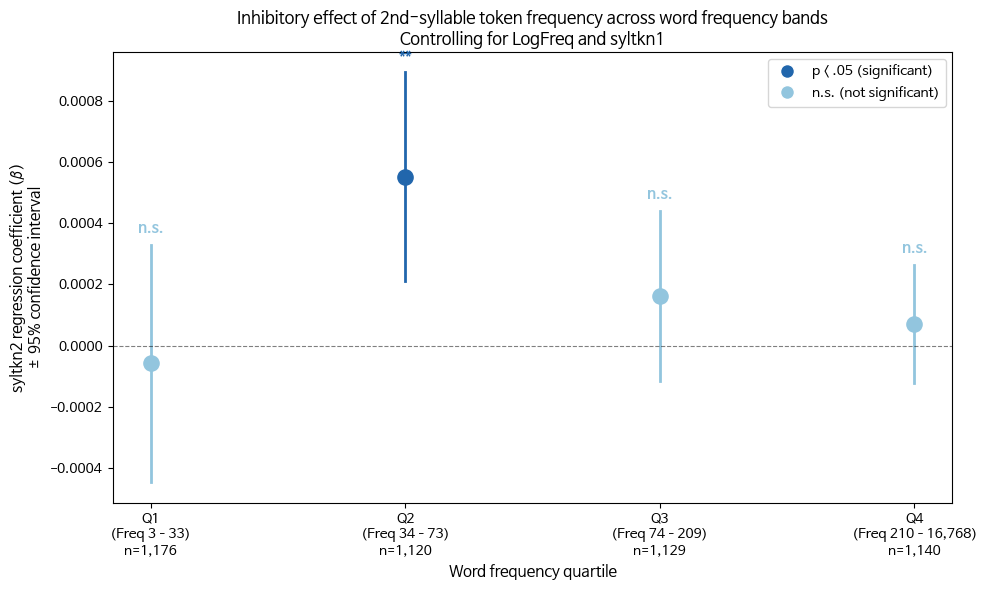

In [12]:
quartiles = ['Q1\n(Freq 3–33)\nn=1,176',
             'Q2\n(Freq 34–73)\nn=1,120',
             'Q3\n(Freq 74–209)\nn=1,129',
             'Q4\n(Freq 210–16,768)\nn=1,140']

betas = [r['beta'] for r in results]
ci_lows = [r['ci_low'] for r in results]
ci_highs = [r['ci_high'] for r in results]
pvals = [r['p'] for r in results]
sigs = [r['sig'] for r in results]

# Colors: significant = darker, n.s. = lighter
colors = ['#2166ac' if p < .05 else '#92c5de' for p in pvals]

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(quartiles))

# Plot confidence interval lines first
for i in range(len(quartiles)):
    ax.plot([x[i], x[i]], [ci_lows[i], ci_highs[i]],
            color=colors[i], linewidth=2, zorder=2)

# Plot beta dots
for i in range(len(quartiles)):
    ax.scatter(x[i], betas[i],
               color=colors[i], s=120, zorder=3,
               label='p < .05' if pvals[i] < .05 else 'n.s.')

# Zero reference line
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

# Significance labels above each point
for i in range(len(quartiles)):
    y_pos = ci_highs[i] + 0.00003
    ax.text(x[i], y_pos, sigs[i],
            ha='center', va='bottom', fontsize=11,
            color=colors[i], fontweight='bold')

# Axis labels and formatting
ax.set_xticks(x)
ax.set_xticklabels(quartiles, fontsize=10)
ax.set_ylabel('syltkn2 regression coefficient (β)\n± 95% confidence interval', fontsize=11)
ax.set_xlabel('Word frequency quartile', fontsize=11)
ax.set_title('Inhibitory effect of 2nd-syllable token frequency across word frequency bands\n'
             'Controlling for LogFreq and syltkn1', fontsize=12)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2166ac',
           markersize=10, label='p < .05 (significant)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#92c5de',
           markersize=10, label='n.s. (not significant)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('quartile_syltkn2_effect.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Create theoretically motivated frequency bands
df_q = df_words[['MRT', 'LogFreq', 'syltkn1', 'syltkn2', 'Freq']].dropna().copy()

bins = [0, 10, 50, 200, float('inf')]
labels = ['Very Low (1–10)', 'Low (11–50)', 'Medium (51–200)', 'High (200+)']
df_q['FreqBand'] = pd.cut(df_q['Freq'], bins=bins, labels=labels)

# Check group sizes
print('Words per frequency band:')
print(df_q['FreqBand'].value_counts().sort_index())
print()

# Run regression within each band
sd_syltkn2 = df_words['syltkn2'].std()
results_band = []

print(f'{"Band":<22} {"n":>5} {"syltkn2 β":>12} {"SE":>10} {"t":>8} {"p":>8} {"sig":>6}  {"effect (ms/SD)":>14}')
print('-' * 95)

for band in ['Very Low (1–10)', 'Low (11–50)', 'Medium (51–200)', 'High (200+)']:
    subset = df_q[df_q['FreqBand'] == band]

    if len(subset) < 30:
        print(f'{band:<22} {len(subset):>5}  -- too few observations --')
        continue

    X = sm.add_constant(subset[['LogFreq', 'syltkn1', 'syltkn2']])
    m = sm.OLS(subset['MRT'], X).fit()

    b = m.params['syltkn2']
    se = m.bse['syltkn2']
    t = m.tvalues['syltkn2']
    p = m.pvalues['syltkn2']
    ci_low = m.conf_int().loc['syltkn2', 0]
    ci_high = m.conf_int().loc['syltkn2', 1]
    sig = '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else 'n.s.'
    effect = b * sd_syltkn2

    print(f'{band:<22} {len(subset):>5} {b:>12.6f} {se:>10.6f} {t:>8.3f} {p:>8.4f}  {sig:>6}  {effect:>14.2f}')

    results_band.append({
        'band': band,
        'n': len(subset),
        'beta': b,
        'se': se,
        'ci_low': ci_low,
        'ci_high': ci_high,
        'p': p,
        'sig': sig,
        'effect': effect
    })

Words per frequency band:
FreqBand
Very Low (1–10)       4
Low (11–50)        1781
Medium (51–200)    1601
High (200+)        1179
Name: count, dtype: int64

Band                       n    syltkn2 β         SE        t        p    sig  effect (ms/SD)
-----------------------------------------------------------------------------------------------
Very Low (1–10)            4  -- too few observations --
Low (11–50)             1781     0.000102   0.000158    0.646   0.5183    n.s.            1.37
Medium (51–200)         1601     0.000285   0.000123    2.323   0.0203       *            3.82
High (200+)             1179     0.000099   0.000097    1.022   0.3070    n.s.            1.33


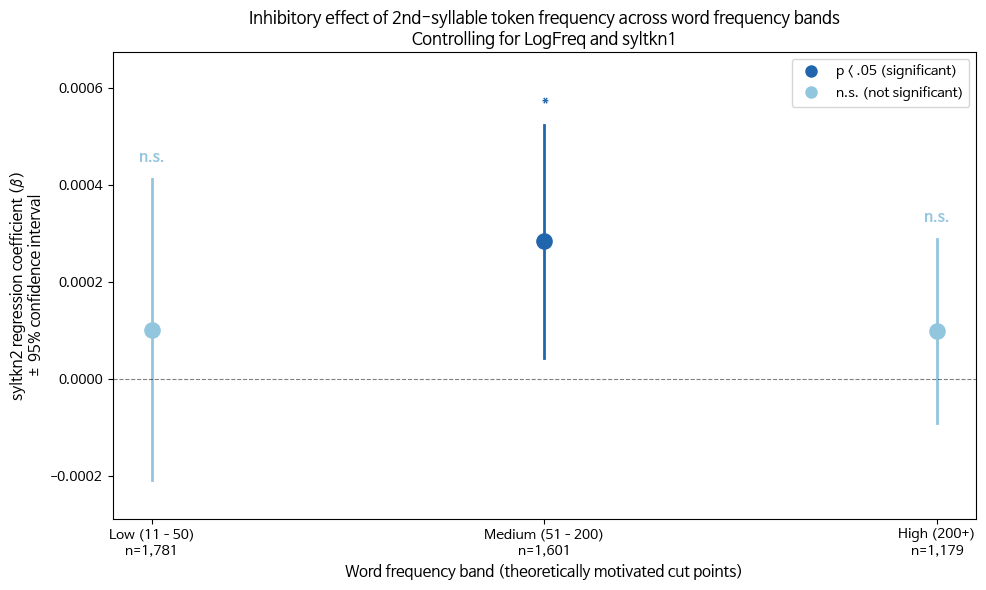

In [14]:
# Use results_band from the theoretically motivated bands
band_labels = [r['band'] for r in results_band]
betas = [r['beta'] for r in results_band]
ci_lows = [r['ci_low'] for r in results_band]
ci_highs = [r['ci_high'] for r in results_band]
pvals = [r['p'] for r in results_band]
sigs = [r['sig'] for r in results_band]
ns = [r['n'] for r in results_band]

# Build x-axis labels with freq range and n from results_band
xticklabels = [f"{band_labels[i]}\nn={ns[i]:,}" for i in range(len(results_band))]

# Colors: significant = darker, n.s. = lighter
colors = ['#2166ac' if p < .05 else '#92c5de' for p in pvals]

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(results_band))

# Plot confidence interval lines
for i in range(len(results_band)):
    ax.plot([x[i], x[i]], [ci_lows[i], ci_highs[i]],
            color=colors[i], linewidth=2, zorder=2)

# Plot beta dots
for i in range(len(results_band)):
    ax.scatter(x[i], betas[i],
               color=colors[i], s=120, zorder=3)

# Zero reference line
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

# Significance labels above each point
for i in range(len(results_band)):
    y_pos = ci_highs[i] + 0.00003
    ax.text(x[i], y_pos, sigs[i],
            ha='center', va='bottom', fontsize=11,
            color=colors[i], fontweight='bold')

# Axis labels and formatting
ax.set_xticks(x)
ax.set_xticklabels(xticklabels, fontsize=10)
ax.set_ylabel('syltkn2 regression coefficient (β)\n± 95% confidence interval', fontsize=11)
ax.set_xlabel('Word frequency band (theoretically motivated cut points)', fontsize=11)
ax.set_title('Inhibitory effect of 2nd-syllable token frequency across word frequency bands\n'
             'Controlling for LogFreq and syltkn1', fontsize=12)

# y-axis room for labels
ax.set_ylim(bottom=min(ci_lows) - 0.00008,
            top=max(ci_highs) + 0.00015)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2166ac',
           markersize=10, label='p < .05 (significant)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#92c5de',
           markersize=10, label='n.s. (not significant)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('freqband_syltkn2_effect.png', dpi=150, bbox_inches='tight')
plt.show()

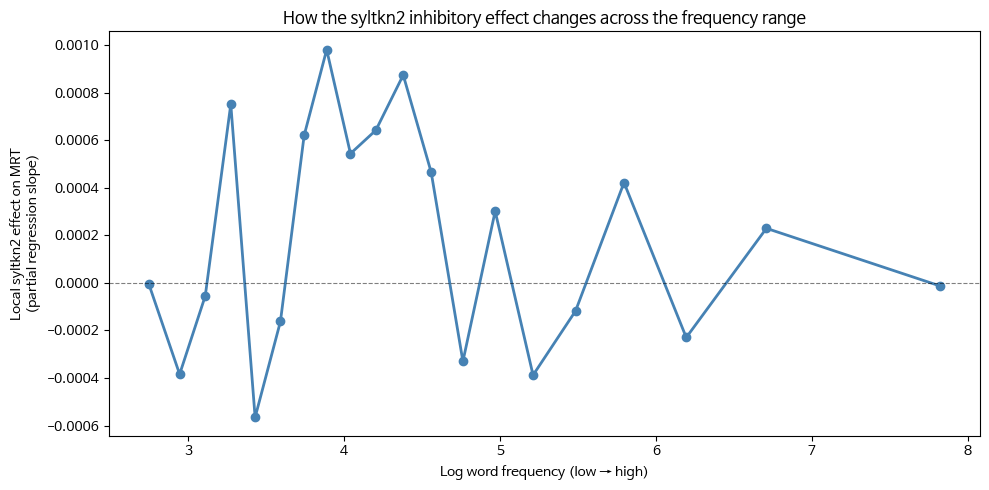

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

df_c = df_words[['MRT', 'LogFreq', 'syltkn1', 'syltkn2']].dropna().copy()

# Get residuals of MRT after removing LogFreq and syltkn1
X_other = sm.add_constant(df_c[['LogFreq', 'syltkn1']])
resid_mrt = sm.OLS(df_c['MRT'], X_other).fit().resid

# Get residuals of syltkn2 after removing LogFreq and syltkn1
resid_tkn2 = sm.OLS(df_c['syltkn2'], X_other).fit().resid

# Now smooth the relationship between resid_tkn2 and resid_mrt
# across the frequency range
df_c['resid_mrt'] = resid_mrt.values
df_c['resid_tkn2'] = resid_tkn2.values

# Split into 20 equal frequency bins and get mean slope in each
df_c['FreqBin'] = pd.qcut(df_c['LogFreq'], q=20)
slopes = []
freq_mids = []

for bin_label, group in df_c.groupby('FreqBin', observed=True):
    if len(group) < 30:
        continue
    if group['resid_tkn2'].std() == 0:
        continue
    m = sm.OLS(group['resid_mrt'],
               sm.add_constant(group['resid_tkn2'])).fit()
    slopes.append(m.params['resid_tkn2'])
    freq_mids.append(group['LogFreq'].mean())

plt.figure(figsize=(10, 5))
plt.plot(freq_mids, slopes, 'o-', color='steelblue', linewidth=2)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
plt.xlabel('Log word frequency (low → high)')
plt.ylabel('Local syltkn2 effect on MRT\n(partial regression slope)')
plt.title('How the syltkn2 inhibitory effect changes across the frequency range')
plt.tight_layout()
plt.show()

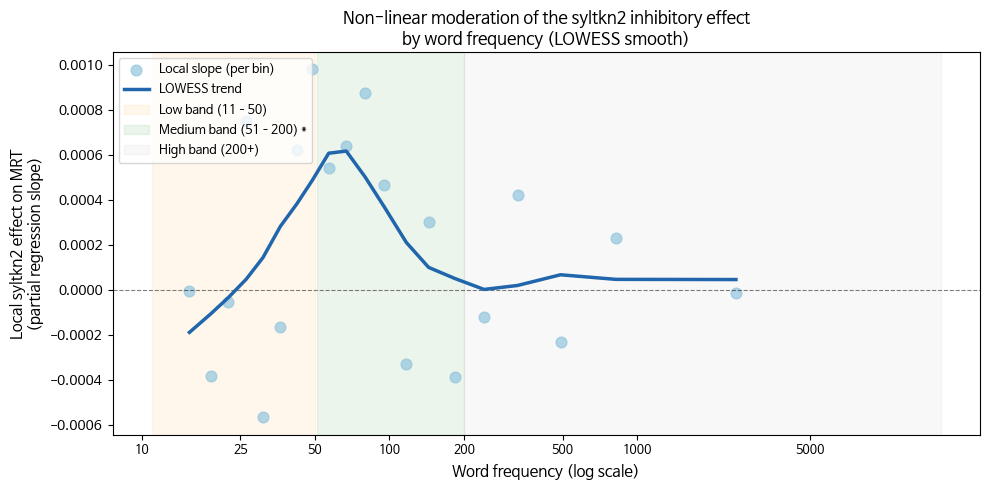

In [16]:
# LOWESS plot: how does the syltkn2 effect change across the frequency range?

df_c = df_words[['MRT', 'LogFreq', 'syltkn1', 'syltkn2']].dropna().copy()

# Step 1: partial out LogFreq and syltkn1 from both MRT and syltkn2
# This isolates the syltkn2 -> MRT relationship after controlling for the other predictors
X_other = sm.add_constant(df_c[['LogFreq', 'syltkn1']])

resid_mrt  = sm.OLS(df_c['MRT'],     X_other).fit().resid
resid_tkn2 = sm.OLS(df_c['syltkn2'], X_other).fit().resid

df_c['resid_mrt']  = resid_mrt.values
df_c['resid_tkn2'] = resid_tkn2.values

# Step 2: bin into 20 equal-count frequency bins, get local slope in each
df_c['FreqBin'] = pd.qcut(df_c['LogFreq'], q=20)

slopes    = []
freq_mids = []
ns_bin    = []

for bin_label, group in df_c.groupby('FreqBin', observed=True):
    if len(group) < 30:
        continue
    if group['resid_tkn2'].std() == 0:
        continue
    local_model = sm.OLS(group['resid_mrt'],
                         sm.add_constant(group['resid_tkn2'])).fit()
    slopes.append(local_model.params['resid_tkn2'])
    freq_mids.append(group['LogFreq'].mean())
    ns_bin.append(len(group))

# Step 3: plot local slopes with LOWESS smoother over them
from statsmodels.nonparametric.smoothers_lowess import lowess

smoothed = lowess(slopes, freq_mids, frac=0.5)

fig, ax = plt.subplots(figsize=(10, 5))

# Raw local slopes as dots
ax.scatter(freq_mids, slopes,
           color='#92c5de', s=60, alpha=0.7, zorder=2, label='Local slope (per bin)')

# LOWESS smooth curve
ax.plot(smoothed[:, 0], smoothed[:, 1],
        color='#2166ac', linewidth=2.5, zorder=3, label='LOWESS trend')

# Zero reference
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

# Shade the "Low" and "Medium" bands from your theory-based cut points
# LogFreq of 10 = ln(10) ≈ 2.30, LogFreq of 50 = ln(50) ≈ 3.91, LogFreq of 200 = ln(200) ≈ 5.30
ax.axvspan(np.log(11), np.log(50),  alpha=0.08, color='orange', label='Low band (11–50)')
ax.axvspan(np.log(51), np.log(200), alpha=0.08, color='green',  label='Medium band (51–200) *')
ax.axvspan(np.log(200), df_c['LogFreq'].max(), alpha=0.05, color='gray', label='High band (200+)')

# X-axis ticks at meaningful frequency values
freq_ticks = [10, 25, 50, 100, 200, 500, 1000, 5000]
ax.set_xticks([np.log(f) for f in freq_ticks])
ax.set_xticklabels([str(f) for f in freq_ticks], fontsize=9)

ax.set_xlabel('Word frequency (log scale)', fontsize=11)
ax.set_ylabel('Local syltkn2 effect on MRT\n(partial regression slope)', fontsize=11)
ax.set_title('Non-linear moderation of the syltkn2 inhibitory effect\nby word frequency (LOWESS smooth)',
             fontsize=12)
ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('lowess_syltkn2_moderation.png', dpi=150, bbox_inches='tight')
plt.show()

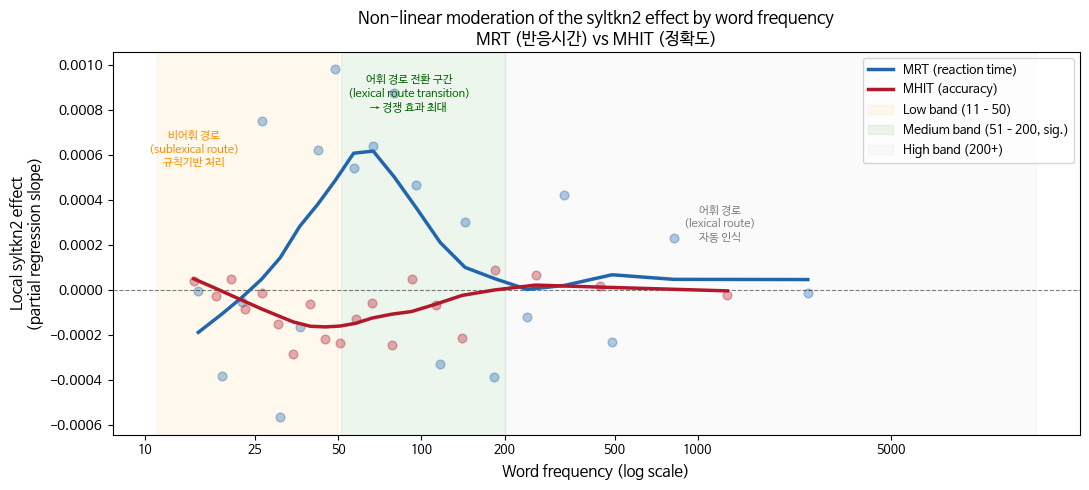

In [18]:
fig, ax = plt.subplots(figsize=(11, 5))

dvs = {
    'MRT': {'color': '#2166ac', 'label': 'MRT (reaction time)'},
    'MHIT': {'color': '#b2182b', 'label': 'MHIT (accuracy)'}
}

for dv, style in dvs.items():
    df_c = df_words[['MRT', 'MHIT', 'LogFreq', 'syltkn1', 'syltkn2']].dropna().copy()

    # For MHIT use sub-ceiling sample
    if dv == 'MHIT':
        df_c = df_c[df_c['MHIT'] < 100].copy()

    X_other = sm.add_constant(df_c[['LogFreq', 'syltkn1']])
    resid_dv   = sm.OLS(df_c[dv],       X_other).fit().resid
    resid_tkn2 = sm.OLS(df_c['syltkn2'], X_other).fit().resid

    df_c['resid_dv']   = resid_dv.values
    df_c['resid_tkn2'] = resid_tkn2.values
    df_c['FreqBin']    = pd.qcut(df_c['LogFreq'], q=20)

    slopes    = []
    freq_mids = []

    for bin_label, group in df_c.groupby('FreqBin', observed=True):
        if len(group) < 30 or group['resid_tkn2'].std() == 0:
            continue
        local_model = sm.OLS(group['resid_dv'],
                             sm.add_constant(group['resid_tkn2'])).fit()
        slopes.append(local_model.params['resid_tkn2'])
        freq_mids.append(group['LogFreq'].mean())

    smoothed = lowess(slopes, freq_mids, frac=0.5)

    # Scatter dots
    ax.scatter(freq_mids, slopes,
               color=style['color'], s=40, alpha=0.35, zorder=2)

    # LOWESS line
    ax.plot(smoothed[:, 0], smoothed[:, 1],
            color=style['color'], linewidth=2.5,
            zorder=3, label=style['label'])

# Zero reference
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

# Frequency band shading
ax.axvspan(np.log(11),  np.log(50),  alpha=0.07, color='orange', label='Low band (11–50)')
ax.axvspan(np.log(51), np.log(200), alpha=0.07, color='green',
           label='Medium band (51–200, sig.)')
ax.axvspan(np.log(200), df_words['LogFreq'].max(), alpha=0.04, color='gray', label='High band (200+)')

# X ticks at meaningful values
freq_ticks = [10, 25, 50, 100, 200, 500, 1000, 5000]
ax.set_xticks([np.log(f) for f in freq_ticks])
ax.set_xticklabels([str(f) for f in freq_ticks], fontsize=9)

ax.set_xlabel('Word frequency (log scale)', fontsize=11)
ax.set_ylabel('Local syltkn2 effect\n(partial regression slope)', fontsize=11)
ax.set_title('Non-linear moderation of the syltkn2 effect by word frequency\n'
             'MRT (반응시간) vs MHIT (정확도)', fontsize=12)
ax.legend(fontsize=9, loc='upper right')

# Add text annotations to the LOWESS plot
ax.text(np.log(15), 0.00055,
        '비어휘 경로\n(sublexical route)\n규칙기반 처리',
        fontsize=8, ha='center', color='darkorange', style='italic')

ax.text(np.log(90), 0.00080,  # was 0.00065, move up to 0.00080
        '어휘 경로 전환 구간\n(lexical route transition)\n→ 경쟁 효과 최대',
        fontsize=8, ha='center', color='darkgreen', style='italic')

ax.text(np.log(1200), 0.00022,  # shift right and up slightly
        '어휘 경로\n(lexical route)\n자동 인식',
        fontsize=8, ha='center', color='gray', style='italic')

plt.tight_layout()
plt.savefig('lowess_mrt_vs_mhit.png', dpi=150, bbox_inches='tight')
plt.show()